In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Real Estate in ISTANBUL (Emlakjet).csv to Real Estate in ISTANBUL (Emlakjet) (1).csv


In [ ]:
df = pd.read_csv("Real Estate in ISTANBUL (Emlakjet).csv")
df.head()


,İlan_Numarası,İlan_Güncelleme_Tarihi,Kategorisi,Brüt_Metrekare,Binanın_Yaşı,Binanın_Kat_Sayısı,Kullanım_Durumu,Yatırıma_Uygunluk,Eşya_Durumu,Banyo_Sayısı,...,Site_İçerisinde,Takas,Fiyat_Durumu,Fiyatı,İl,İlçe,Mahalle,yaka,Yaşam_endeksi,Nüfus
0,2003,02 Şubat 2022,Satılık,190,5-10,20,Kiracı Oturuyor,Bilinmiyor,Yok,2,...,Hayır,Var,Genel Fiyat,18000000,İstanbul,Beşiktaş,Nisbetiye Mahallesi,Avrupa Yakası,0.911,178.938
1,166,14 Ocak 2022,Satılık,300,21 Ve Üzeri,2,Kiracı Oturuyor,Bilinmiyor,Yok,3,...,Hayır,Var,Genel Fiyat,8500000,İstanbul,Beşiktaş,Akat Mahallesi,Avrupa Yakası,0.911,178.938
2,167,14 Ocak 2022,Satılık,350,21 Ve Üzeri,3,Mülk Sahibi Oturuyor,Bilinmiyor,Yok,2,...,Hayır,Var,Genel Fiyat,16500000,İstanbul,Beşiktaş,Levent Mahallesi,Avrupa Yakası,0.911,178.938
3,115,06 Ocak 2022,Satılık,450,5-10,4,Kiracı Oturuyor,Bilinmiyor,Yok,3,...,Hayır,Var,Genel Fiyat,22000000,İstanbul,Beşiktaş,Levazım Mahallesi,Avrupa Yakası,0.911,178.938
4,2879,08 Şubat 2022,Satılık,160,21 Ve Üzeri,2,Mülk Sahibi Oturuyor,Bilinmiyor,Yok,1,...,Hayır,Var,Genel Fiyat,4250000,İstanbul,Beşiktaş,Nisbetiye Mahallesi,Avrupa Yakası,0.911,178.938


In [ ]:
df.columns

Index(['İlan_Numarası', 'İlan_Güncelleme_Tarihi', 'Kategorisi',
       'Brüt_Metrekare', 'Binanın_Yaşı', 'Binanın_Kat_Sayısı',
       'Kullanım_Durumu', 'Yatırıma_Uygunluk', 'Eşya_Durumu', 'Banyo_Sayısı',
       'İlan_Oluşturma_Tarihi', 'Türü', 'Net_Metrekare', 'Oda_Sayısı',
       'Bulunduğu_Kat', 'Isıtma_Tipi', 'Krediye_Uygunluk', 'Site_İçerisinde',
       'Takas', 'Fiyat_Durumu', 'Fiyatı', 'İl', 'İlçe', 'Mahalle', 'yaka',
       'Yaşam_endeksi', 'Nüfus'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2983 entries, 0 to 2982
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   İlan_Numarası           2983 non-null   int64  
 1   İlan_Güncelleme_Tarihi  2983 non-null   object 
 2   Kategorisi              2983 non-null   object 
 3   Brüt_Metrekare          2983 non-null   int64  
 4   Binanın_Yaşı            2983 non-null   object 
 5   Binanın_Kat_Sayısı      2983 non-null   int64  
 6   Kullanım_Durumu         2983 non-null   object 
 7   Yatırıma_Uygunluk       2983 non-null   object 
 8   Eşya_Durumu             2983 non-null   object 
 9   Banyo_Sayısı            2983 non-null   object 
 10  İlan_Oluşturma_Tarihi   2983 non-null   object 
 11  Türü                    2983 non-null   object 
 12  Net_Metrekare           2983 non-null   int64  
 13  Oda_Sayısı              2983 non-null   object 
 14  Bulunduğu_Kat           2983 non-null   

In [ ]:
# Binanın_Yaşı sütunundaki kategorileri sayısal değerlere dönüştür
df['Binanın_Yaşı'].value_counts()

# Örnek dönüşüm: yaş aralıklarını ortalama yaşa çevir
yas_map = {
    '0': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    '5': 5,
    '6-10': 8,
    '11-15': 13,
    '16-20': 18,
    '21 Ve Üzeri': 25,
    '5-10': 8
}

df['Binanın_Yaşı_Num'] = df['Binanın_Yaşı'].map(yas_map)


In [ ]:
# Önce boşlukları temizle
df['Banyo_Sayısı'] = df['Banyo_Sayısı'].astype(str).str.strip()

# Sayıya çevrilebilenleri al, 'Yok' → 0, diğer metinleri NaN yap
def temiz_banyo_sayisi(x):
    if x.lower() == 'yok':
        return 0
    try:
        return int(x)
    except:
        return np.nan

df['Banyo_Sayısı_Num'] = df['Banyo_Sayısı'].apply(temiz_banyo_sayisi)




In [ ]:
df['Banyo_Sayısı_Num'].value_counts(dropna=False)


,count
Banyo_Sayısı_Num,
1.0,1414
2.0,1147
3.0,232
4.0,69
NaN,66
0.0,28
5.0,25
1075.0,1
15.0,1


In [ ]:
# Mantıklı aralıkta olmayan banyo sayıları NaN yapılabilir (örneğin 0–6 arası)
df.loc[(df['Banyo_Sayısı_Num'] < 0) | (df['Banyo_Sayısı_Num'] > 6), 'Banyo_Sayısı_Num'] = np.nan


In [ ]:
# Oda sayısı genelde '2+1', '3+1' gibi formatta
df['Oda_Sayısı'].value_counts()

# Fonksiyon: '3+1' → 4 gibi toplam oda sayısını hesaplar
def oda_sayisi_toplam(x):
    try:
        parts = x.split('+')
        return int(parts[0]) + int(parts[1])
    except:
        return np.nan

df['Toplam_Oda_Sayısı'] = df['Oda_Sayısı'].apply(oda_sayisi_toplam)


In [ ]:
# Benzersiz değerleri ve kaç kez geçtiğini görelim
df['Bulunduğu_Kat'].value_counts(dropna=False)


,count
Bulunduğu_Kat,
1. Kat,350
2. Kat,347
4. Kat,338
3. Kat,321
Düz Giriş,246
Bahçe Katı,240
5. Kat,212
Yüksek Giriş,172
7. Kat,101


In [ ]:
def bulunduğu_kat_donusum(x):
    x = str(x).strip().lower()

    # Zemin katlar
    if x in ['bahçe katı', 'yüksek giriş', 'düz giriş']:
        return 0

    # Belirsiz veya kat kavramı olmayanlar
    if any(kelime in x for kelime in ['çatı', 'dubleks', 'teras', 'villa', 'müstakil', 'bodrum']):
        return np.nan

    # Kot katlar
    if 'kot 1' in x:
        return -1
    elif 'kot 2' in x:
        return -2
    elif 'kot 3' in x:
        return -3

    # Aralıklar
    if '10-20' in x:
        return 15
    elif '30-40' in x:
        return 35

    # Sayıya çevrilebilenler
    try:
        return int(re.findall(r'\d+', x)[0])
    except:
        return np.nan

df['Bulunduğu_Kat_Num'] = df['Bulunduğu_Kat'].apply(bulunduğu_kat_donusum)


In [ ]:
df['Bulunduğu_Kat_Num'].value_counts(dropna=False).sort_index()


,count
Bulunduğu_Kat_Num,
-3.0,2
-2.0,7
-1.0,11
0.0,658
1.0,350
2.0,347
3.0,321
4.0,338
5.0,212


In [ ]:
df['Isıtma_Tipi'] = df['Isıtma_Tipi'].astype(str).str.strip()
df['Isıtma_Tipi'].value_counts(dropna=False)


,count
Isıtma_Tipi,
Doğalgaz,2873
Yerden Isıtma,74
Isıtma Yok,20
Klimalı,8
Sobalı,8


In [ ]:
# One-hot encoding ile ısıtma tipini sayısal hale getir
isitma_encoded = pd.get_dummies(df['Isıtma_Tipi'], prefix='Isıtma')

# Yeni sütunları orijinal veriyle birleştir
df = pd.concat([df, isitma_encoded], axis=1)


In [ ]:
df.filter(like='Isıtma_').head()


,Isıtma_Tipi,Isıtma_Doğalgaz,Isıtma_Isıtma Yok,Isıtma_Klimalı,Isıtma_Sobalı,Isıtma_Yerden Isıtma
0,Klimalı,False,False,True,False,False
1,Doğalgaz,True,False,False,False,False
2,Doğalgaz,True,False,False,False,False
3,Doğalgaz,True,False,False,False,False
4,Doğalgaz,True,False,False,False,False


In [ ]:
# Sadece one-hot sütunlarını seç (Isıtma_ ile başlayıp tipi olmayanlar)
isitma_cols = [col for col in df.columns if col.startswith('Isıtma_') and col != 'Isıtma_Tipi']
df[isitma_cols] = df[isitma_cols].astype(int)



In [ ]:
df[isitma_cols].head()


,Isıtma_Doğalgaz,Isıtma_Isıtma Yok,Isıtma_Klimalı,Isıtma_Sobalı,Isıtma_Yerden Isıtma
0,0,0,1,0,0
1,1,0,0,0,0
2,1,0,0,0,0
3,1,0,0,0,0
4,1,0,0,0,0


In [ ]:
df['Kullanım_Durumu'] = df['Kullanım_Durumu'].astype(str).str.strip()
df['Kullanım_Durumu'].value_counts(dropna=False)


,count
Kullanım_Durumu,
Boş,1402
Mülk Sahibi Oturuyor,847
Kiracı Oturuyor,734


In [ ]:
# One-hot encoding ile kullanım durumu sütununu dönüştür
kullanim_encoded = pd.get_dummies(df['Kullanım_Durumu'], prefix='Kullanım')

# Yeni sütunları veri çerçevesine ekle
df = pd.concat([df, kullanim_encoded], axis=1)

# Sayısal hale getir (True/False → 1/0)
kullanim_cols = kullanim_encoded.columns
df[kullanim_cols] = df[kullanim_cols].astype(int)


In [ ]:
df[kullanim_cols].head()


,Kullanım_Boş,Kullanım_Kiracı Oturuyor,Kullanım_Mülk Sahibi Oturuyor
0,0,1,0
1,0,1,0
2,0,0,1
3,0,1,0
4,0,0,1


In [ ]:
df['Site_İçerisinde'] = df['Site_İçerisinde'].astype(str).str.strip()
df['Site_İçerisinde'].value_counts(dropna=False)


,count
Site_İçerisinde,
Hayır,2972
Evet,11


In [ ]:
# 'Evet' → 1, 'Hayır' → 0
df['Site_İçerisinde_Binary'] = df['Site_İçerisinde'].map({'Evet': 1, 'Hayır': 0})


In [ ]:
df['Site_İçerisinde_Binary'].value_counts()


,count
Site_İçerisinde_Binary,
0,2972
1,11


In [ ]:
df['Takas'] = df['Takas'].astype(str).str.strip()
df['Takas'].value_counts(dropna=False)


,count
Takas,
Var,2983


In [ ]:
df['Krediye_Uygunluk'] = df['Krediye_Uygunluk'].astype(str).str.strip()
df['Krediye_Uygunluk'].value_counts(dropna=False)


,count
Krediye_Uygunluk,
KREDIYE UYGUN,2605
Krediye Uygun Değil,363
Bilinmiyor,15


In [ ]:
# One-hot encoding ile kredi uygunluğunu dönüştür
kredi_encoded = pd.get_dummies(df['Krediye_Uygunluk'], prefix='Kredi')

# Yeni sütunları veri çerçevesine ekle
df = pd.concat([df, kredi_encoded], axis=1)

# Sayısal hale getir (True/False → 1/0)
kredi_cols = kredi_encoded.columns
df[kredi_cols] = df[kredi_cols].astype(int)


In [ ]:
df[kredi_cols].head()


,Kredi_Bilinmiyor,Kredi_KREDIYE UYGUN,Kredi_Krediye Uygun Değil
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


In [ ]:
df['İl'].value_counts(dropna=False)


,count
İl,
İstanbul,2983


In [ ]:
print("İlçe sayısı:", df['İlçe'].nunique())
print("Mahalle sayısı:", df['Mahalle'].nunique())


İlçe sayısı: 13
Mahalle sayısı: 210


In [ ]:
ilce_encoded = pd.get_dummies(df['İlçe'], prefix='İlçe')
df = pd.concat([df, ilce_encoded], axis=1)
df[ilce_encoded.columns] = df[ilce_encoded.columns].astype(int)


In [ ]:
# Her mahalleye ortalama fiyatı ata
mahalle_fiyat_map = df.groupby('Mahalle')['Fiyatı'].mean()
df['Mahalle_Target'] = df['Mahalle'].map(mahalle_fiyat_map)


In [ ]:
df[['Mahalle', 'Mahalle_Target']].drop_duplicates().sort_values('Mahalle_Target', ascending=False).head()


,Mahalle,Mahalle_Target
2802,Emirgan Mahallesi,1.143333e+08
2886,Yeniköy Mahallesi,1.033000e+08
78,Vişnezade Mahallesi,4.764222e+07
2789,Baltalimanı Mahallesi,3.500000e+07
16,Mecidiye Mahallesi,3.123333e+07


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2983 entries, 0 to 2982
Data columns (total 57 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   İlan_Numarası                  2983 non-null   int64  
 1   İlan_Güncelleme_Tarihi         2983 non-null   object 
 2   Kategorisi                     2983 non-null   object 
 3   Brüt_Metrekare                 2983 non-null   int64  
 4   Binanın_Yaşı                   2983 non-null   object 
 5   Binanın_Kat_Sayısı             2983 non-null   int64  
 6   Kullanım_Durumu                2983 non-null   object 
 7   Yatırıma_Uygunluk              2983 non-null   object 
 8   Eşya_Durumu                    2983 non-null   object 
 9   Banyo_Sayısı                   2983 non-null   object 
 10  İlan_Oluşturma_Tarihi          2983 non-null   object 
 11  Türü                           2983 non-null   object 
 12  Net_Metrekare                  2983 non-null   i

In [ ]:
# İlçe sütunlarını liste olarak al
ilce_cols = list(df.columns[df.columns.str.startswith('İlçe_')])
isitma_cols = list(df.columns[df.columns.str.startswith('Isıtma_') & (df.columns != 'Isıtma_Tipi')])
kullanim_cols = list(df.columns[df.columns.str.startswith('Kullanım_')])
kredi_cols = list(df.columns[df.columns.str.startswith('Kredi_')])

# Sayısal sütunlar
numeric_cols = [
    'Net_Metrekare', 'Brüt_Metrekare', 'Binanın_Kat_Sayısı',
    'Binanın_Yaşı_Num', 'Banyo_Sayısı_Num', 'Toplam_Oda_Sayısı',
    'Bulunduğu_Kat_Num', 'Yaşam_endeksi', 'Nüfus',
    'Mahalle_Target',  # veya 'Mahalle_Target_Log'
    'Site_İçerisinde_Binary'
]

# Tüm öznitelikleri birleştir
model_features = numeric_cols + isitma_cols + kullanim_cols + kredi_cols + ilce_cols


In [ ]:
print("Toplam öznitelik sayısı:", len(model_features))


Toplam öznitelik sayısı: 36


In [ ]:
df[model_features].isnull().sum().sort_values(ascending=False)


,0
Binanın_Yaşı_Num,2983
Toplam_Oda_Sayısı,106
Banyo_Sayısı_Num,68
Bulunduğu_Kat_Num,44
Binanın_Kat_Sayısı,0
Brüt_Metrekare,0
Net_Metrekare,0
Yaşam_endeksi,0
Nüfus,0
Mahalle_Target,0


In [ ]:
df['Binanın_Yaşı'].unique()


array(['5-10 ', '21 Ve Üzeri ', '16-20 ', '0 (Yeni) ', '4 ', '2 ', '1 ',
       '11-15 ', '3 '], dtype=object)

In [ ]:
def donustur_bina_yasi(yas):
    yas = str(yas).strip().lower()

    if 'yeni' in yas or yas.startswith('0'):
        return 0
    elif 've üzeri' in yas:
        return 21
    elif '-' in yas:
        try:
            alt, ust = yas.replace(' ', '').split('-')
            return round((int(alt) + int(ust)) / 2)
        except:
            return np.nan
    elif yas.isdigit():
        return int(yas)
    else:
        return np.nan


In [ ]:
df['Binanın_Yaşı_Num'].describe()


,Binanın_Yaşı_Num
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [ ]:
for val in df['Binanın_Yaşı'].unique():
    print(val, '→', donustur_bina_yasi(val))


5-10  → 8
21 Ve Üzeri  → 21
16-20  → 18
0 (Yeni)  → 0
4  → 4
2  → 2
1  → 1
11-15  → 13
3  → 3


In [ ]:
def donustur_bina_yasi(yas):
    yas = str(yas).strip().lower().replace(' ', '')

    if 'yeni' in yas or yas.startswith('0'):
        return 0
    elif 'veüzeri' in yas:
        return 21
    elif '-' in yas:
        try:
            alt, ust = yas.split('-')
            return round((int(alt) + int(ust)) / 2)
        except:
            return np.nan
    elif yas.isdigit():
        return int(yas)
    else:
        return np.nan


In [ ]:
df['Binanın_Yaşı_Num'] = df['Binanın_Yaşı'].apply(donustur_bina_yasi)


In [ ]:
df['Binanın_Yaşı_Num'].describe()


,Binanın_Yaşı_Num
count,2983.000000
mean,7.634931
std,7.619811
min,0.000000
25%,0.000000
50%,4.000000
75%,13.000000
max,21.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2983 entries, 0 to 2982
Data columns (total 57 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   İlan_Numarası                  2983 non-null   int64  
 1   İlan_Güncelleme_Tarihi         2983 non-null   object 
 2   Kategorisi                     2983 non-null   object 
 3   Brüt_Metrekare                 2983 non-null   int64  
 4   Binanın_Yaşı                   2983 non-null   object 
 5   Binanın_Kat_Sayısı             2983 non-null   int64  
 6   Kullanım_Durumu                2983 non-null   object 
 7   Yatırıma_Uygunluk              2983 non-null   object 
 8   Eşya_Durumu                    2983 non-null   object 
 9   Banyo_Sayısı                   2983 non-null   object 
 10  İlan_Oluşturma_Tarihi          2983 non-null   object 
 11  Türü                           2983 non-null   object 
 12  Net_Metrekare                  2983 non-null   i

In [ ]:
df['Kategorisi'].value_counts()

,count
Kategorisi,
Satılık,2983


In [ ]:
df['Yatırıma_Uygunluk'].value_counts()


,count
Yatırıma_Uygunluk,
Bilinmiyor,2791
Hayır,153
Yatırıma Uygun,24
Evet,15


In [ ]:
df['Eşya_Durumu'].value_counts()


,count
Eşya_Durumu,
Yok,2769
Var,214


In [ ]:
df['Eşya_Binary'] = df['Eşya_Durumu'].map({
    'Var': 1,
    'Yok': 0
})


In [ ]:
df['Fiyat_Durumu'].value_counts()


,count
Fiyat_Durumu,
Genel Fiyat,2874
Birim Fiyat,90
Hayır,15
Evet,4


In [ ]:
df['Fiyat_Tipi'] = df['Fiyat_Durumu'].map({
    'Genel Fiyat': 'Genel',
    'Birim Fiyat': 'Birim'
})


In [ ]:
df['Pazarlık'] = df['Fiyat_Durumu'].map({
    'Evet': 1,
    'Hayır': 0
})


In [ ]:
df['Türü'].value_counts()


,count
Türü,
Konut,2983


In [ ]:
df['yaka'].value_counts()


,count
yaka,
Avrupa Yakası,2091
Anadolu Yakası,892


In [ ]:
df['Yaka_Binary'] = df['yaka'].map({
    'Avrupa Yakası': 1,
    'Anadolu Yakası': 0
})


In [ ]:
df['İlan_Güncelleme_Tarihi'].head()

,İlan_Güncelleme_Tarihi
0,02 Şubat 2022
1,14 Ocak 2022
2,14 Ocak 2022
3,06 Ocak 2022
4,08 Şubat 2022


In [ ]:
ay_map = {
    'Ocak': 'January', 'Şubat': 'February', 'Mart': 'March',
    'Nisan': 'April', 'Mayıs': 'May', 'Haziran': 'June',
    'Temmuz': 'July', 'Ağustos': 'August', 'Eylül': 'September',
    'Ekim': 'October', 'Kasım': 'November', 'Aralık': 'December'
}

df['İlan_Güncelleme_Tarihi_Eng'] = df['İlan_Güncelleme_Tarihi'].replace(ay_map, regex=True)
df['İlan_Oluşturma_Tarihi_Eng'] = df['İlan_Oluşturma_Tarihi'].replace(ay_map, regex=True)


In [ ]:
df['İlan_Güncelleme_Tarihi_Eng'] = df['İlan_Güncelleme_Tarihi_Eng'].str.strip()
df['İlan_Oluşturma_Tarihi_Eng'] = df['İlan_Oluşturma_Tarihi_Eng'].str.strip()


In [ ]:
df['İlan_Güncelleme_Tarihi_DT'] = pd.to_datetime(df['İlan_Güncelleme_Tarihi_Eng'], format='%d %B %Y')
df['İlan_Oluşturma_Tarihi_DT'] = pd.to_datetime(df['İlan_Oluşturma_Tarihi_Eng'], format='%d %B %Y')



In [ ]:
mask = ~df['İlan_Güncelleme_Tarihi_Eng'].str.match(r'^\d{2} [A-Za-z]+ \d{4}$')
df[mask]['İlan_Güncelleme_Tarihi_Eng']


,İlan_Güncelleme_Tarihi_Eng


In [ ]:
'İlan_Güncelleme_Tarihi_Eng' in df.columns


True

In [ ]:
df['İlan_Güncelleme_Tarihi_Eng'].head(10)


,İlan_Güncelleme_Tarihi_Eng
0,02 February 2022
1,14 January 2022
2,14 January 2022
3,06 January 2022
4,08 February 2022
5,08 February 2022
6,07 February 2022
7,06 February 2022
8,06 February 2022
9,07 February 2022


In [ ]:
df['İlan_Güncelleme_Tarihi_Eng'].str.match(r'^\d{2} [A-Za-z]+ \d{4}$').value_counts()


,count
İlan_Güncelleme_Tarihi_Eng,
True,2983


In [ ]:
df['İlan_Güncelleme_Tarihi_Eng'] = pd.to_datetime(df['İlan_Güncelleme_Tarihi_Eng'], format='%d %B %Y')


In [ ]:
df['İlan_Güncelleme_Tarihi_Eng'].head(10)

,İlan_Güncelleme_Tarihi_Eng
0,2022-02-02
1,2022-01-14
2,2022-01-14
3,2022-01-06
4,2022-02-08
5,2022-02-08
6,2022-02-07
7,2022-02-06
8,2022-02-06
9,2022-02-07


In [ ]:
df['Güncelleme_Yıl'] = df['İlan_Güncelleme_Tarihi_Eng'].dt.year
df['Güncelleme_Ay'] = df['İlan_Güncelleme_Tarihi_Eng'].dt.month
df['Güncelleme_Gün'] = df['İlan_Güncelleme_Tarihi_Eng'].dt.day
df['Güncelleme_Haftası'] = df['İlan_Güncelleme_Tarihi_Eng'].dt.isocalendar().week
df['Güncelleme_Günü'] = df['İlan_Güncelleme_Tarihi_Eng'].dt.dayofweek  # Pazartesi=0


In [ ]:
from datetime import datetime
df['Güncelleme_İlan_Yaşı'] = (datetime.today() - df['İlan_Güncelleme_Tarihi_Eng']).dt.days


In [ ]:
df[['İlan_Güncelleme_Tarihi_Eng', 'Güncelleme_Yıl', 'Güncelleme_Ay',
    'Güncelleme_Gün', 'Güncelleme_Haftası', 'Güncelleme_Günü', 'Güncelleme_İlan_Yaşı']].head()


,İlan_Güncelleme_Tarihi_Eng,Güncelleme_Yıl,Güncelleme_Ay,Güncelleme_Gün,Güncelleme_Haftası,Güncelleme_Günü,Güncelleme_İlan_Yaşı
0,2022-02-02,2022,2,2,5,2,1289
1,2022-01-14,2022,1,14,2,4,1308
2,2022-01-14,2022,1,14,2,4,1308
3,2022-01-06,2022,1,6,1,3,1316
4,2022-02-08,2022,2,8,6,1,1283


In [ ]:
'İlan_Oluşturma_Tarihi' in df.columns


True

In [ ]:
df['İlan_Oluşturma_Tarihi_Eng'] = df['İlan_Oluşturma_Tarihi'].str.replace('Ocak', 'January') \
    .str.replace('Şubat', 'February') \
    .str.replace('Mart', 'March') \
    .str.replace('Nisan', 'April') \
    .str.replace('Mayıs', 'May') \
    .str.replace('Haziran', 'June') \
    .str.replace('Temmuz', 'July') \
    .str.replace('Ağustos', 'August') \
    .str.replace('Eylül', 'September') \
    .str.replace('Ekim', 'October') \
    .str.replace('Kasım', 'November') \
    .str.replace('Aralık', 'December')


In [ ]:
df['İlan_Oluşturma_Tarihi_Eng'] = pd.to_datetime(df['İlan_Oluşturma_Tarihi_Eng'], errors='coerce')


In [ ]:
df['Yayında_Kalma_Süresi'] = (df['İlan_Güncelleme_Tarihi_Eng'] - df['İlan_Oluşturma_Tarihi_Eng']).dt.days


In [ ]:
df[['İlan_Oluşturma_Tarihi_Eng', 'İlan_Güncelleme_Tarihi_Eng', 'Yayında_Kalma_Süresi']].head(10)


,İlan_Oluşturma_Tarihi_Eng,İlan_Güncelleme_Tarihi_Eng,Yayında_Kalma_Süresi
0,2022-01-27,2022-02-02,6
1,2021-10-15,2022-01-14,91
2,2021-10-15,2022-01-14,91
3,2021-09-22,2022-01-06,106
4,2022-02-08,2022-02-08,0
5,2022-02-08,2022-02-08,0
6,2022-02-07,2022-02-07,0
7,2022-02-06,2022-02-06,0
8,2022-02-06,2022-02-06,0
9,2022-02-07,2022-02-07,0


In [ ]:
df[df['Yayında_Kalma_Süresi'] < 0]


,İlan_Numarası,İlan_Güncelleme_Tarihi,Kategorisi,Brüt_Metrekare,Binanın_Yaşı,Binanın_Kat_Sayısı,Kullanım_Durumu,Yatırıma_Uygunluk,Eşya_Durumu,Banyo_Sayısı,...,İlan_Oluşturma_Tarihi_Eng,İlan_Güncelleme_Tarihi_DT,İlan_Oluşturma_Tarihi_DT,Güncelleme_Yıl,Güncelleme_Ay,Güncelleme_Gün,Güncelleme_Haftası,Güncelleme_Günü,Güncelleme_İlan_Yaşı,Yayında_Kalma_Süresi


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2983 entries, 0 to 2982
Data columns (total 72 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   İlan_Numarası                  2983 non-null   int64         
 1   İlan_Güncelleme_Tarihi         2983 non-null   object        
 2   Kategorisi                     2983 non-null   object        
 3   Brüt_Metrekare                 2983 non-null   int64         
 4   Binanın_Yaşı                   2983 non-null   object        
 5   Binanın_Kat_Sayısı             2983 non-null   int64         
 6   Kullanım_Durumu                2983 non-null   object        
 7   Yatırıma_Uygunluk              2983 non-null   object        
 8   Eşya_Durumu                    2983 non-null   object        
 9   Banyo_Sayısı                   2983 non-null   object        
 10  İlan_Oluşturma_Tarihi          2983 non-null   object        
 11  Türü             

In [ ]:
missing = df.isna().sum()
missing[missing > 0]


,0
Banyo_Sayısı_Num,68
Toplam_Oda_Sayısı,106
Bulunduğu_Kat_Num,44
Fiyat_Tipi,2983
Pazarlık,2983


In [ ]:
df[['Fiyat_Tipi', 'Pazarlık']].dropna().head()


,Fiyat_Tipi,Pazarlık


In [ ]:
df.drop(columns=['Fiyat_Tipi', 'Pazarlık'], inplace=True)


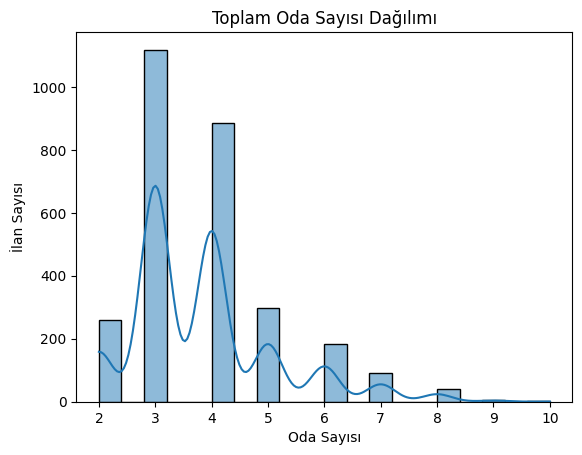

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Toplam_Oda_Sayısı'], bins=20, kde=True)
plt.title('Toplam Oda Sayısı Dağılımı')
plt.xlabel('Oda Sayısı')
plt.ylabel('İlan Sayısı')
plt.show()


In [ ]:
Q1 = df['Toplam_Oda_Sayısı'].quantile(0.25)
Q3 = df['Toplam_Oda_Sayısı'].quantile(0.75)
IQR = Q3 - Q1


In [ ]:
alt_sınır = Q1 - 1.5 * IQR
üst_sınır = Q3 + 1.5 * IQR


In [ ]:
medyan_iqr = df[(df['Toplam_Oda_Sayısı'] >= alt_sınır) & (df['Toplam_Oda_Sayısı'] <= üst_sınır)]['Toplam_Oda_Sayısı'].median()


In [ ]:
df['Toplam_Oda_Sayısı'] = df['Toplam_Oda_Sayısı'].fillna(medyan_iqr)


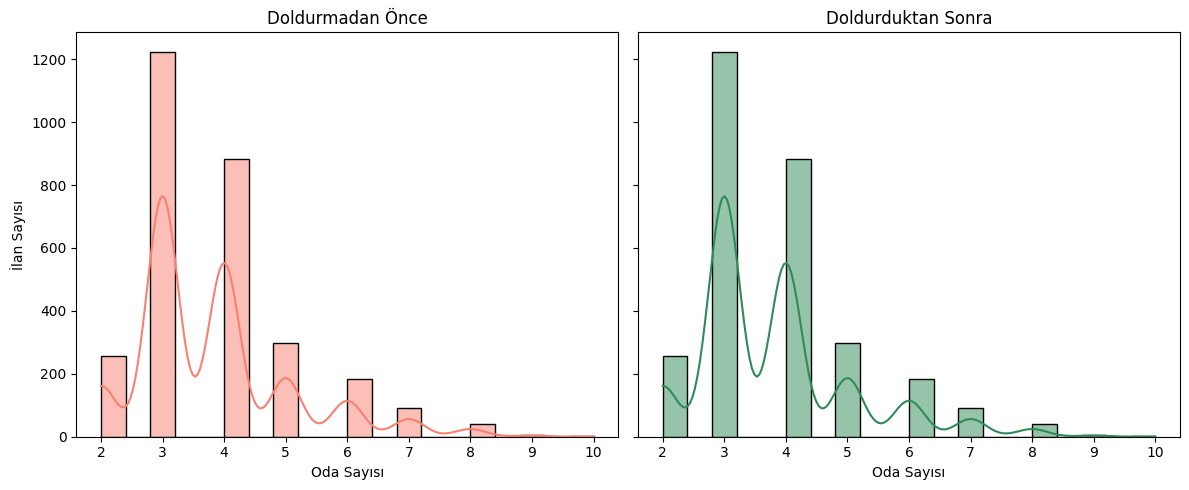

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Eksik doldurmadan önceki hali yedekle
oda_before = df['Toplam_Oda_Sayısı'].copy()

# 2. IQR ile medyanı hesapla
Q1 = oda_before.quantile(0.25)
Q3 = oda_before.quantile(0.75)
IQR = Q3 - Q1
alt_sınır = Q1 - 1.5 * IQR
üst_sınır = Q3 + 1.5 * IQR
medyan_iqr = oda_before[(oda_before >= alt_sınır) & (oda_before <= üst_sınır)].median()

# 3. Eksik değerleri doldur
oda_after = oda_before.fillna(medyan_iqr)

# 4. Yan yana görselleştir
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.histplot(oda_before, bins=20, kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Doldurmadan Önce')
axes[0].set_xlabel('Oda Sayısı')
axes[0].set_ylabel('İlan Sayısı')

sns.histplot(oda_after, bins=20, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Doldurduktan Sonra')
axes[1].set_xlabel('Oda Sayısı')

plt.tight_layout()
plt.show()


In [ ]:
# IQR hesapla
Q1_banyo = df['Banyo_Sayısı_Num'].quantile(0.25)
Q3_banyo = df['Banyo_Sayısı_Num'].quantile(0.75)
IQR_banyo = Q3_banyo - Q1_banyo

# Aykırı olmayan değerlerin medyanı
alt_banyo = Q1_banyo - 1.5 * IQR_banyo
üst_banyo = Q3_banyo + 1.5 * IQR_banyo
medyan_banyo_iqr = df[(df['Banyo_Sayısı_Num'] >= alt_banyo) & (df['Banyo_Sayısı_Num'] <= üst_banyo)]['Banyo_Sayısı_Num'].median()


In [ ]:
df['Banyo_Sayısı_Num'] = df['Banyo_Sayısı_Num'].fillna(medyan_banyo_iqr)


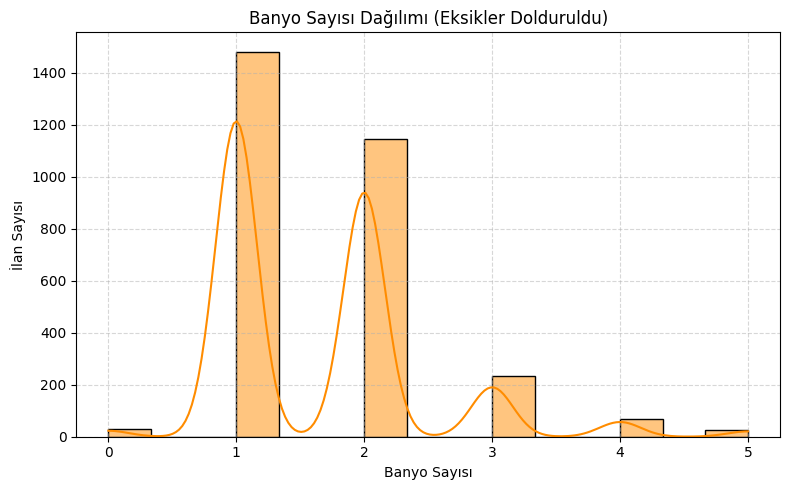

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(df['Banyo_Sayısı_Num'], bins=15, kde=True, color='darkorange')
plt.title('Banyo Sayısı Dağılımı (Eksikler Dolduruldu)')
plt.xlabel('Banyo Sayısı')
plt.ylabel('İlan Sayısı')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# IQR hesapla
Q1_kat = df['Bulunduğu_Kat_Num'].quantile(0.25)
Q3_kat = df['Bulunduğu_Kat_Num'].quantile(0.75)
IQR_kat = Q3_kat - Q1_kat

# Aykırı olmayan değerlerin medyanı
alt_kat = Q1_kat - 1.5 * IQR_kat
üst_kat = Q3_kat + 1.5 * IQR_kat
medyan_kat_iqr = df[(df['Bulunduğu_Kat_Num'] >= alt_kat) & (df['Bulunduğu_Kat_Num'] <= üst_kat)]['Bulunduğu_Kat_Num'].median()


In [ ]:
df['Bulunduğu_Kat_Num'] = df['Bulunduğu_Kat_Num'].fillna(medyan_kat_iqr)


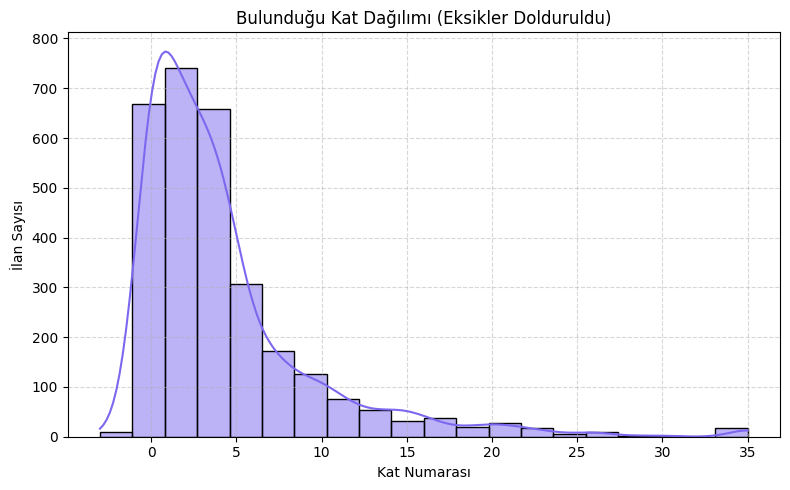

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(df['Bulunduğu_Kat_Num'], bins=20, kde=True, color='mediumslateblue')
plt.title('Bulunduğu Kat Dağılımı (Eksikler Dolduruldu)')
plt.xlabel('Kat Numarası')
plt.ylabel('İlan Sayısı')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2983 entries, 0 to 2982
Data columns (total 70 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   İlan_Numarası                  2983 non-null   int64         
 1   İlan_Güncelleme_Tarihi         2983 non-null   object        
 2   Kategorisi                     2983 non-null   object        
 3   Brüt_Metrekare                 2983 non-null   int64         
 4   Binanın_Yaşı                   2983 non-null   object        
 5   Binanın_Kat_Sayısı             2983 non-null   int64         
 6   Kullanım_Durumu                2983 non-null   object        
 7   Yatırıma_Uygunluk              2983 non-null   object        
 8   Eşya_Durumu                    2983 non-null   object        
 9   Banyo_Sayısı                   2983 non-null   object        
 10  İlan_Oluşturma_Tarihi          2983 non-null   object        
 11  Türü             

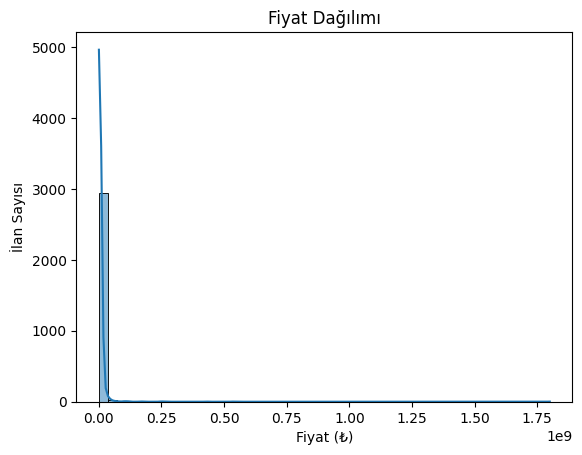

In [ ]:
sns.histplot(df['Fiyatı'], bins=50, kde=True)
plt.title('Fiyat Dağılımı')
plt.xlabel('Fiyat (₺)')
plt.ylabel('İlan Sayısı')
plt.show()


In [ ]:
import numpy as np
df['Fiyat_Log'] = np.log1p(df['Fiyatı'])


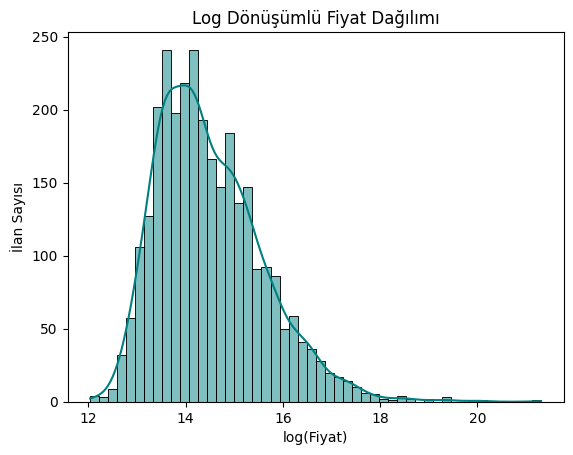

In [ ]:
sns.histplot(df['Fiyat_Log'], bins=50, kde=True, color='teal')
plt.title('Log Dönüşümlü Fiyat Dağılımı')
plt.xlabel('log(Fiyat)')
plt.ylabel('İlan Sayısı')
plt.show()


In [ ]:
df['Fiyat_Brut_m2'] = df['Fiyatı'] / df['Brüt_Metrekare']


In [ ]:
df['Fiyat_Net_m2'] = df['Fiyatı'] / df['Net_Metrekare']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2983 entries, 0 to 2982
Data columns (total 73 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   İlan_Numarası                  2983 non-null   int64         
 1   İlan_Güncelleme_Tarihi         2983 non-null   object        
 2   Kategorisi                     2983 non-null   object        
 3   Brüt_Metrekare                 2983 non-null   int64         
 4   Binanın_Yaşı                   2983 non-null   object        
 5   Binanın_Kat_Sayısı             2983 non-null   int64         
 6   Kullanım_Durumu                2983 non-null   object        
 7   Yatırıma_Uygunluk              2983 non-null   object        
 8   Eşya_Durumu                    2983 non-null   object        
 9   Banyo_Sayısı                   2983 non-null   object        
 10  İlan_Oluşturma_Tarihi          2983 non-null   object        
 11  Türü             

In [ ]:
cat_cols = ['Kategorisi', 'Binanın_Yaşı', 'Yatırıma_Uygunluk', 'Eşya_Durumu',
            'Banyo_Sayısı', 'Türü', 'yaka']

for col in cat_cols:
    print(f"{col}: {df[col].nunique()} kategori")


Kategorisi: 1 kategori
Binanın_Yaşı: 9 kategori
Yatırıma_Uygunluk: 4 kategori
Eşya_Durumu: 2 kategori
Banyo_Sayısı: 12 kategori
Türü: 1 kategori
yaka: 2 kategori


In [ ]:
onehot_cols = ['Binanın_Yaşı', 'Yatırıma_Uygunluk']
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)


In [ ]:
print(df['Banyo_Sayısı'].unique())

['2' '3' '1' '4' '5' 'Yok' 'Var' '6+' 'Genel Fiyat' '28 M2' '1075' '15']


In [ ]:
print(df['Banyo_Sayısı'].value_counts(dropna=False).sort_index())


Banyo_Sayısı
1              1414
1075              1
15                1
2              1147
28 M2             1
3               232
4                69
5                25
6+               24
Genel Fiyat      19
Var              22
Yok              28
Name: count, dtype: int64


In [ ]:
#median_banyo = df['Banyo_Sayısı_Clean'].median()
#print(f"Medyan banyo sayısı: {median_banyo}")


In [ ]:
df['Banyo_Sayısı_Clean'] = df['Banyo_Sayısı'].replace({
    'Yok': 0,
    'Var': np.nan,
    '6+': 6,
    '15': 10,
    '1075': np.nan,
    '28 M2': np.nan,
    'Genel Fiyat': np.nan
}).astype(float)


In [ ]:
print(df['Banyo_Sayısı_Clean'].value_counts(dropna=False).sort_index())


Banyo_Sayısı_Clean
0.0       28
1.0     1414
2.0     1147
3.0      232
4.0       69
5.0       25
6.0       24
10.0       1
NaN       43
Name: count, dtype: int64


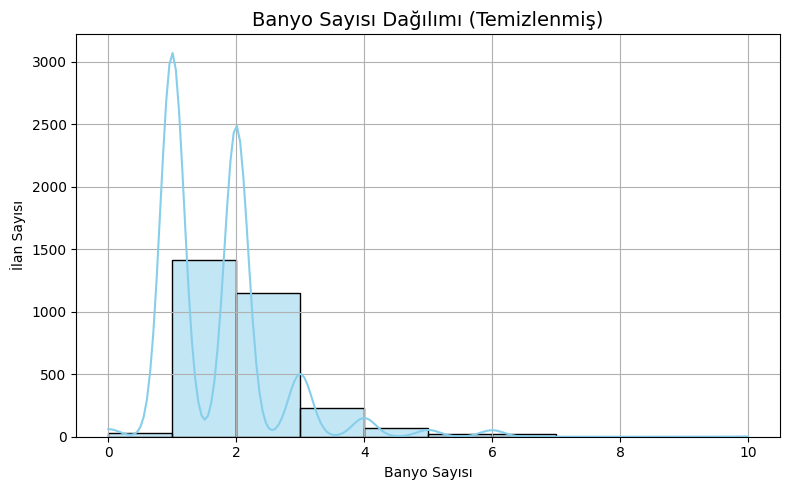

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Banyo_Sayısı_Clean'], bins=10, kde=True, color='skyblue')
plt.title('Banyo Sayısı Dağılımı (Temizlenmiş)', fontsize=14)
plt.xlabel('Banyo Sayısı')
plt.ylabel('İlan Sayısı')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
df['Banyo_Sayısı_Clean'] = df['Banyo_Sayısı_Clean'].fillna(2.0)


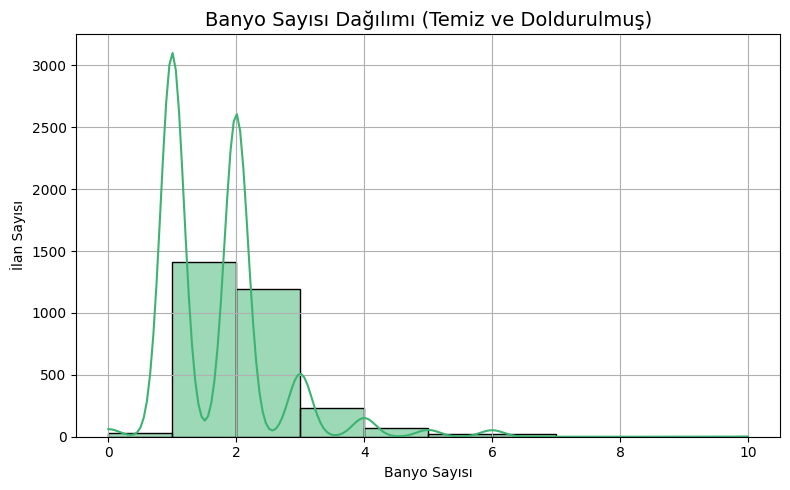

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Banyo_Sayısı_Clean'], bins=10, kde=True, color='mediumseagreen')
plt.title('Banyo Sayısı Dağılımı (Temiz ve Doldurulmuş)', fontsize=14)
plt.xlabel('Banyo Sayısı')
plt.ylabel('İlan Sayısı')
plt.grid(True)
plt.tight_layout()
plt.show()


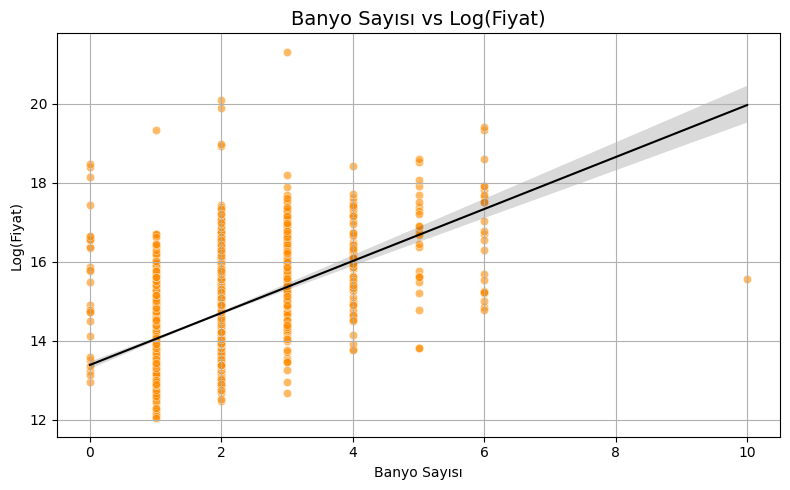

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Banyo_Sayısı_Clean', y='Fiyat_Log', data=df, alpha=0.6, color='darkorange')
sns.regplot(x='Banyo_Sayısı_Clean', y='Fiyat_Log', data=df, scatter=False, color='black', line_kws={'linewidth':1.5})
plt.title('Banyo Sayısı vs Log(Fiyat)', fontsize=14)
plt.xlabel('Banyo Sayısı')
plt.ylabel('Log(Fiyat)')
plt.grid(True)
plt.tight_layout()
plt.show()


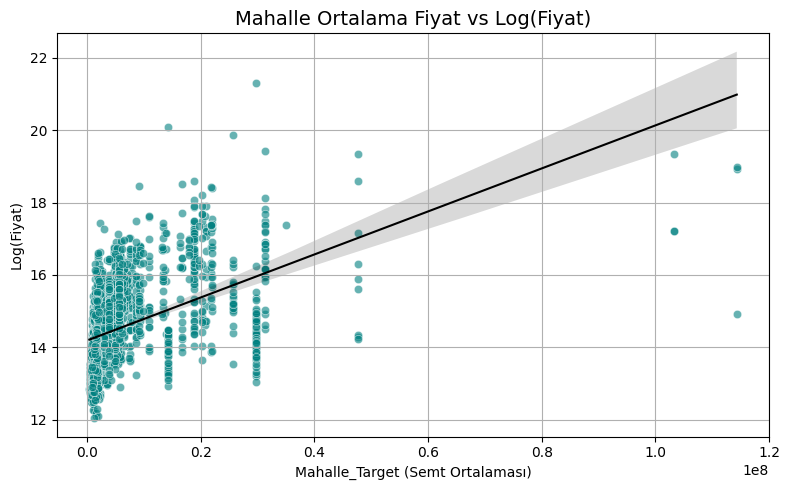

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Mahalle_Target', y='Fiyat_Log', data=df, alpha=0.6, color='teal')
sns.regplot(x='Mahalle_Target', y='Fiyat_Log', data=df, scatter=False, color='black', line_kws={'linewidth':1.5})
plt.title('Mahalle Ortalama Fiyat vs Log(Fiyat)', fontsize=14)
plt.xlabel('Mahalle_Target (Semt Ortalaması)')
plt.ylabel('Log(Fiyat)')
plt.grid(True)
plt.tight_layout()
plt.show()


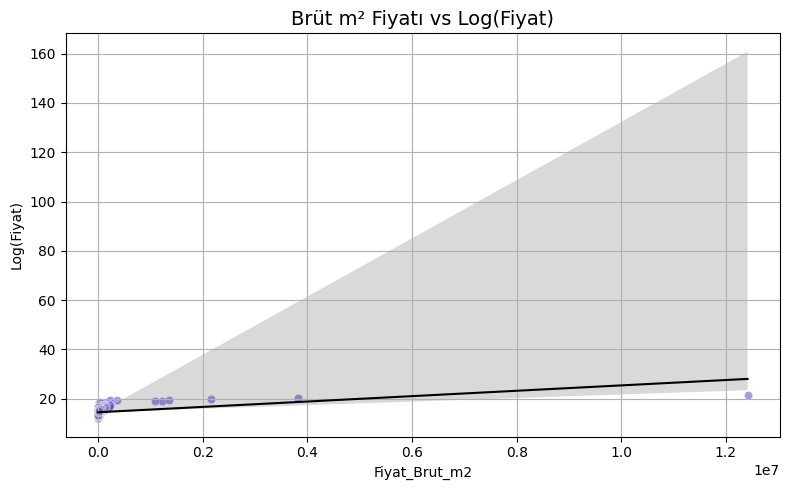

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Fiyat_Brut_m2', y='Fiyat_Log', data=df, alpha=0.6, color='slateblue')
sns.regplot(x='Fiyat_Brut_m2', y='Fiyat_Log', data=df, scatter=False, color='black', line_kws={'linewidth':1.5})
plt.title('Brüt m² Fiyatı vs Log(Fiyat)', fontsize=14)
plt.xlabel('Fiyat_Brut_m2')
plt.ylabel('Log(Fiyat)')
plt.grid(True)
plt.tight_layout()
plt.show()


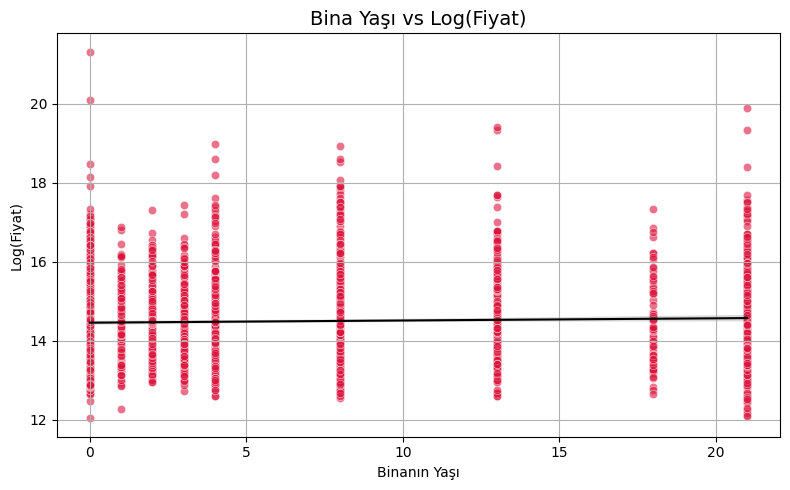

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Binanın_Yaşı_Num', y='Fiyat_Log', data=df, alpha=0.6, color='crimson')
sns.regplot(x='Binanın_Yaşı_Num', y='Fiyat_Log', data=df, scatter=False, color='black', line_kws={'linewidth':1.5})
plt.title('Bina Yaşı vs Log(Fiyat)', fontsize=14)
plt.xlabel('Binanın Yaşı')
plt.ylabel('Log(Fiyat)')
plt.grid(True)
plt.tight_layout()
plt.show()


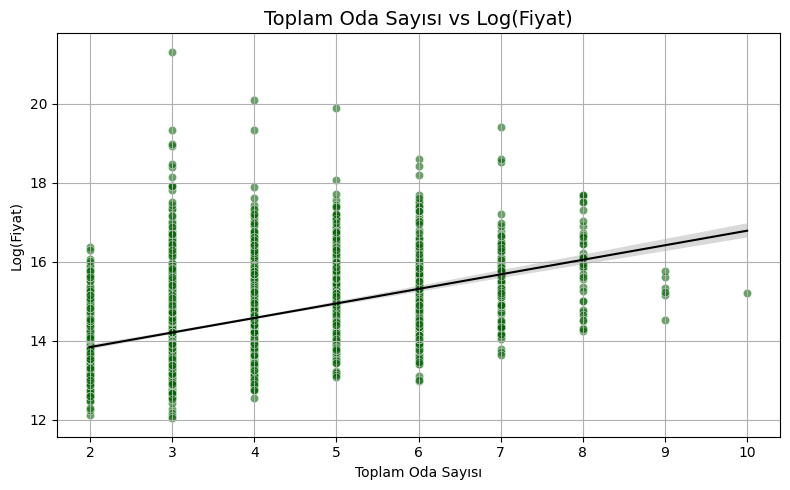

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Toplam_Oda_Sayısı', y='Fiyat_Log', data=df, alpha=0.6, color='darkgreen')
sns.regplot(x='Toplam_Oda_Sayısı', y='Fiyat_Log', data=df, scatter=False, color='black', line_kws={'linewidth':1.5})
plt.title('Toplam Oda Sayısı vs Log(Fiyat)', fontsize=14)
plt.xlabel('Toplam Oda Sayısı')
plt.ylabel('Log(Fiyat)')
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
features = [
    'Brüt_Metrekare', 'Net_Metrekare', 'Toplam_Oda_Sayısı', 'Banyo_Sayısı_Clean',
    'Binanın_Yaşı_Num', 'Yaşam_endeksi', 'Nüfus', 'Mahalle_Target',
    'Eşya_Binary', 'Yaka_Binary', 'Site_İçerisinde_Binary'
]

# One-hot sütunları da ekleyelim:
onehot_cols = [col for col in df.columns if col.startswith('Isıtma_') or
               col.startswith('Kullanım_') or col.startswith('Kredi_') or
               col.startswith('İlçe_')]

features += onehot_cols


In [ ]:
df.replace("Boş", np.nan, inplace=True)


In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)


In [ ]:
df = pd.get_dummies(df, columns=['Kullanım_Durumu'], drop_first=True)


In [ ]:
onehot_cols = [col for col in df.columns if col.startswith('Kullanım_Durumu_')]
features += onehot_cols


In [ ]:
onehot_cols = [col for col in df.columns if col.startswith('Kullanım_Durumu_')]


In [ ]:
features = [col for col in features if col != 'Kullanım_Durumu']
features += onehot_cols


In [ ]:
df = pd.get_dummies(df, columns=['Isıtma_Tipi'], drop_first=True)


In [ ]:
onehot_cols = [col for col in df.columns if col.startswith('Isıtma_Tipi_')]
features = [col for col in features if col != 'Isıtma_Tipi']
features += onehot_cols


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Özellikler ve hedef
X = df[features]
y = df['Fiyat_Log']

# Veri setini ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli kur ve eğit
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Tahmin
y_pred_lr = lr_model.predict(X_test)

# Performans metrikleri
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\n Lineer Regresyon Performansı")
print(f"MSE  : {mse_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"MAE  : {mae_lr:.2f}")
print(f"R²   : {r2_lr:.2f}")



 Lineer Regresyon Performansı
MSE  : 0.47
RMSE : 0.69
MAE  : 0.46
R²   : 0.56


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Modeli kur ve eğit
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Tahmin
y_pred_dt = dt_model.predict(X_test)

# Performans metrikleri
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("\n Karar Ağacı Performansı")
print(f"MSE  : {mse_dt:.2f}")
print(f"RMSE : {rmse_dt:.2f}")
print(f"MAE  : {mae_dt:.2f}")
print(f"R²   : {r2_dt:.2f}")



 Karar Ağacı Performansı
MSE  : 0.49
RMSE : 0.70
MAE  : 0.50
R²   : 0.55


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Modeli kur ve eğit
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Tahmin
y_pred_rf = rf_model.predict(X_test)

# Performans metrikleri
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n Rastgele Orman Performansı")
print(f"MSE  : {mse_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"MAE  : {mae_rf:.2f}")
print(f"R²   : {r2_rf:.2f}")



 Rastgele Orman Performansı
MSE  : 0.26
RMSE : 0.51
MAE  : 0.37
R²   : 0.76


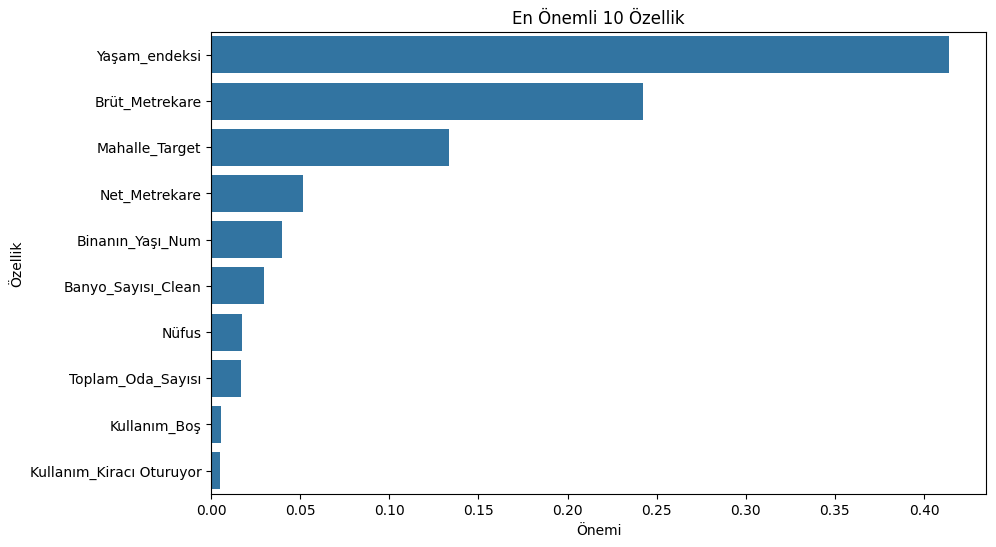

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = feature_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("En Önemli 10 Özellik")
plt.xlabel("Önemi")
plt.ylabel("Özellik")
plt.show()


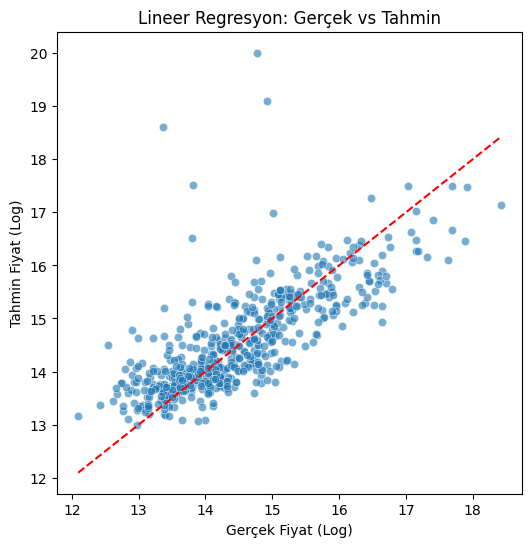

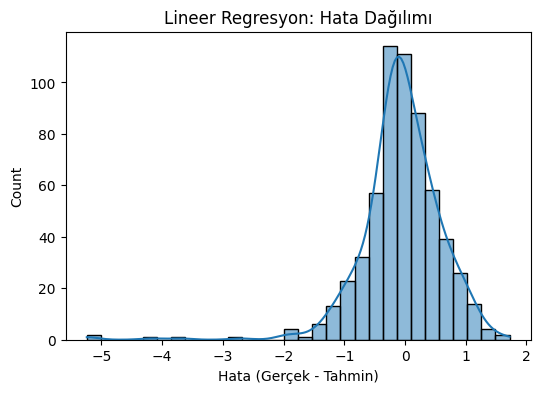

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Tahmin
y_pred_lr = lr_model.predict(X_test)

# Gerçek vs Tahmin
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Gerçek Fiyat (Log)")
plt.ylabel("Tahmin Fiyat (Log)")
plt.title("Lineer Regresyon: Gerçek vs Tahmin")
plt.show()

# Hata Dağılımı
residuals_lr = y_test - y_pred_lr
plt.figure(figsize=(6,4))
sns.histplot(residuals_lr, bins=30, kde=True)
plt.title("Lineer Regresyon: Hata Dağılımı")
plt.xlabel("Hata (Gerçek - Tahmin)")
plt.show()


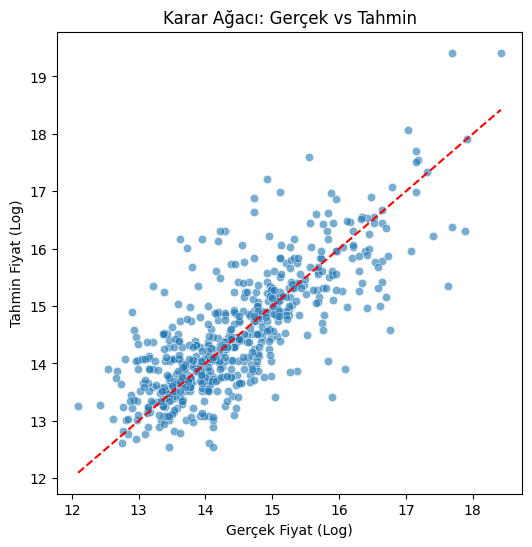

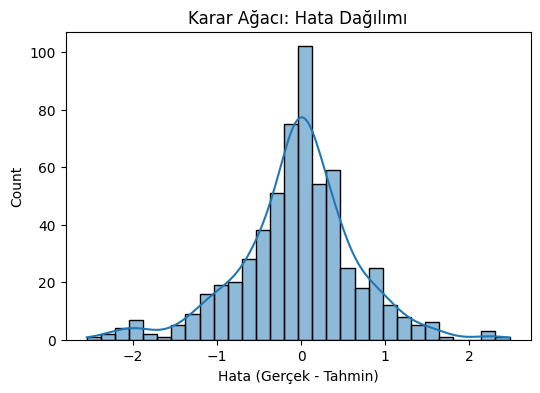

In [ ]:
# Tahmin
y_pred_dt = dt_model.predict(X_test)

# Gerçek vs Tahmin
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_dt, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Gerçek Fiyat (Log)")
plt.ylabel("Tahmin Fiyat (Log)")
plt.title("Karar Ağacı: Gerçek vs Tahmin")
plt.show()

# Hata Dağılımı
residuals_dt = y_test - y_pred_dt
plt.figure(figsize=(6,4))
sns.histplot(residuals_dt, bins=30, kde=True)
plt.title("Karar Ağacı: Hata Dağılımı")
plt.xlabel("Hata (Gerçek - Tahmin)")
plt.show()


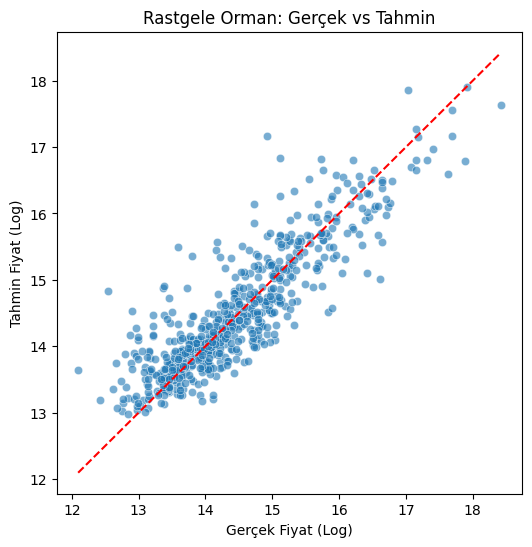

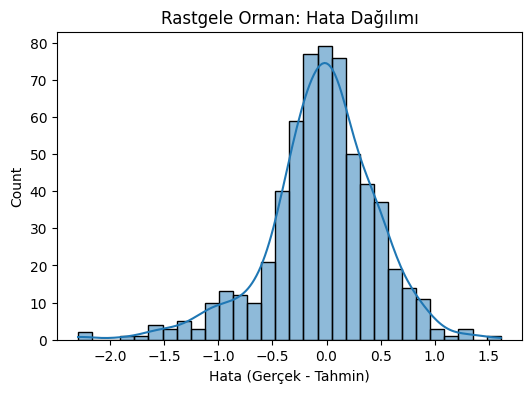

In [ ]:
# Tahmin
y_pred_rf = rf_model.predict(X_test)

# Gerçek vs Tahmin
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Gerçek Fiyat (Log)")
plt.ylabel("Tahmin Fiyat (Log)")
plt.title("Rastgele Orman: Gerçek vs Tahmin")
plt.show()

# Hata Dağılımı
residuals_rf = y_test - y_pred_rf
plt.figure(figsize=(6,4))
sns.histplot(residuals_rf, bins=30, kde=True)
plt.title("Rastgele Orman: Hata Dağılımı")
plt.xlabel("Hata (Gerçek - Tahmin)")
plt.show()


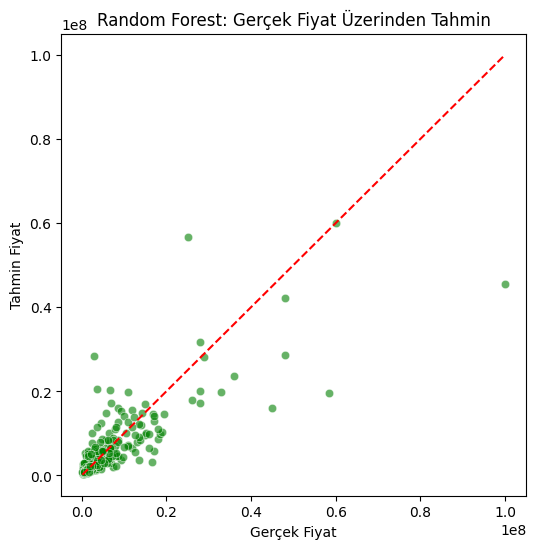

In [ ]:
y_test_real = np.exp(y_test)
y_pred_rf_real = np.exp(y_pred_rf)

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test_real, y=y_pred_rf_real, alpha=0.6, color='green')
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--')
plt.xlabel("Gerçek Fiyat")
plt.ylabel("Tahmin Fiyat")
plt.title("Random Forest: Gerçek Fiyat Üzerinden Tahmin")
plt.show()


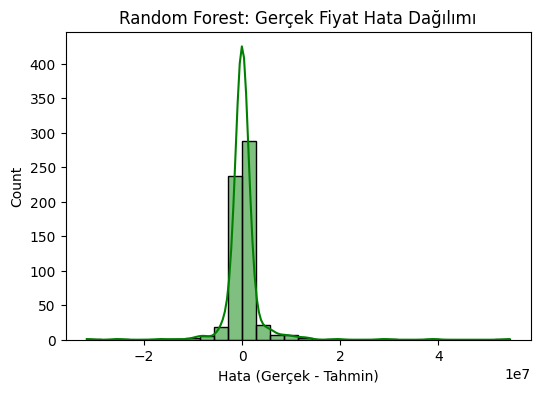

In [ ]:
residuals_rf_real = y_test_real - y_pred_rf_real
plt.figure(figsize=(6,4))
sns.histplot(residuals_rf_real, bins=30, kde=True, color='green')
plt.title("Random Forest: Gerçek Fiyat Hata Dağılımı")
plt.xlabel("Hata (Gerçek - Tahmin)")
plt.show()


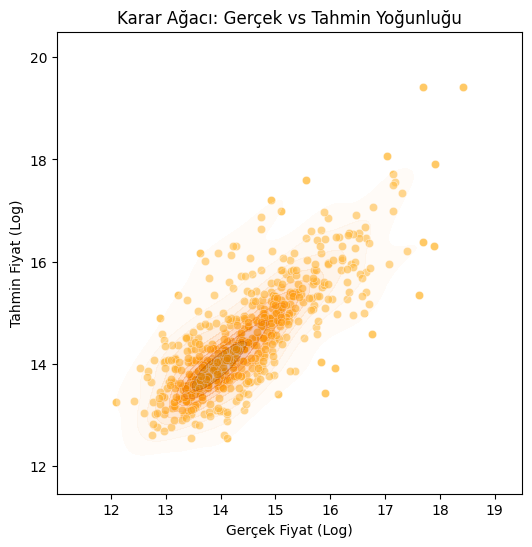

In [ ]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_dt, alpha=0.6, color='orange')
sns.kdeplot(x=y_test, y=y_pred_dt, cmap="Oranges", fill=True, alpha=0.3)
plt.xlabel("Gerçek Fiyat (Log)")
plt.ylabel("Tahmin Fiyat (Log)")
plt.title("Karar Ağacı: Gerçek vs Tahmin Yoğunluğu")
plt.show()


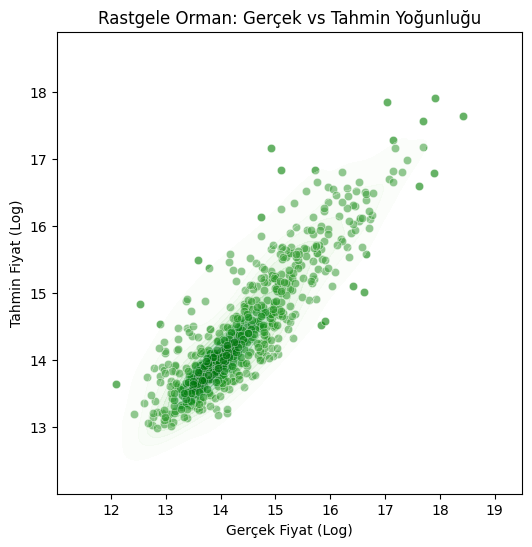

In [ ]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6, color='green')
sns.kdeplot(x=y_test, y=y_pred_rf, cmap="Greens", fill=True, alpha=0.3)
plt.xlabel("Gerçek Fiyat (Log)")
plt.ylabel("Tahmin Fiyat (Log)")
plt.title("Rastgele Orman: Gerçek vs Tahmin Yoğunluğu")
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2983 entries, 0 to 2982
Data columns (total 86 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   İlan_Numarası                         2983 non-null   int64         
 1   İlan_Güncelleme_Tarihi                2983 non-null   object        
 2   Kategorisi                            2983 non-null   object        
 3   Brüt_Metrekare                        2983 non-null   int64         
 4   Binanın_Kat_Sayısı                    2983 non-null   int64         
 5   Eşya_Durumu                           2983 non-null   object        
 6   Banyo_Sayısı                          2983 non-null   object        
 7   İlan_Oluşturma_Tarihi                 2983 non-null   object        
 8   Türü                                  2983 non-null   object        
 9   Net_Metrekare                         2983 non-null   int64         
 10  

In [ ]:
print(X_test)

      Brüt_Metrekare  Net_Metrekare  Binanın_Yaşı_Num  Banyo_Sayısı_Clean  \
2410             190            160                 3                 2.0   
1547             150            120                18                 2.0   
881              126            106                 8                 2.0   
331               90             85                13                 1.0   
1837              85             70                 8                 1.0   
...              ...            ...               ...                 ...   
999              105             90                 0                 1.0   
422              110            100                13                 1.0   
1869             110             85                 4                 1.0   
1429             260            180                 0                 3.0   
2623             185            135                 4                 2.0   

      Toplam_Oda_Sayısı  Bulunduğu_Kat_Num  Yaşam_endeksi    Nüfus  \
2410 

In [ ]:
print(y_test)

2410    14.827112
1547    15.511126
881     14.843343
331     13.458837
1837    13.567050
          ...    
999     14.115616
422     13.329379
1869    14.328335
1429    15.648092
2623    14.502137
Name: Fiyat_Log, Length: 597, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Hedef ve özellikler
target = "Fiyat_Log"
features = [
    "Brüt_Metrekare", "Net_Metrekare", "Binanın_Yaşı_Num", "Banyo_Sayısı_Clean",
    "Toplam_Oda_Sayısı", "Bulunduğu_Kat_Num", "Yaşam_endeksi", "Nüfus",
    "Mahalle_Target", "Site_İçerisinde_Binary", "Kredi_KREDIYE UYGUN",
    "Eşya_Binary", "Yaka_Binary", "Yayında_Kalma_Süresi"
]

X = df[features]
y = df[target]

# 2. Eğitim/test böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model tanımı ve eğitimi
model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 4. Performans değerlendirmesi
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
r2 = r2_score(np.expm1(y_test), np.expm1(y_pred))

print(f"🔍 RMSE: {rmse:,.0f} TL")
print(f"📈 R² Skoru: {r2:.3f}")

# 5. Örnek ev tanımı
example = pd.DataFrame([{
    "Brüt_Metrekare": 190,
    "Net_Metrekare": 160,
    "Binanın_Yaşı_Num": 3,
    "Banyo_Sayısı_Clean": 2.0,
    "Toplam_Oda_Sayısı": 6.0,
    "Bulunduğu_Kat_Num": 5.0,
    "Yaşam_endeksi": 0.161,
    "Nüfus": 525.566,
    "Mahalle_Target": 29676690.0,
    "Site_İçerisinde_Binary": 0,
    "Kredi_KREDIYE UYGUN": 1,
    "Eşya_Binary": 0,
    "Yaka_Binary": 0,
    "Yayında_Kalma_Süresi": 2
}])


# 6. Tahmin
log_price = model.predict(example)[0]
price = np.expm1(log_price)

sample_index = 2410
true_price = np.expm1(y_test.loc[sample_index])

print(f"🏠 Tahmini fiyat: {price:,.0f} TL")
print(f"✅ Gerçek fiyat: {true_price:,.0f} TL")

🔍 RMSE: 4,378,882 TL
📈 R² Skoru: 0.661
🏠 Tahmini fiyat: 2,457,210 TL
✅ Gerçek fiyat: 2,750,000 TL
